In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Student Performance Analysis System")
print("Libraries imported successfully!")

Student Performance Analysis System
Libraries imported successfully!


In [4]:
students = {
    "Student_ID": [
        "ST101", "ST102", "ST103", "ST104", "ST105",
        "ST106", "ST107", "ST108", "ST109", "ST110"
    ],
    "Study_Hours": [2, 5, 3, 8, 6, 1, 7, 4, 9, 5],
    "Attendance": [65, 85, 70, 95, 88, 50, 92, 75, 98, 80],
    "Math_Marks": [42, 78, 55, 92, 81, 30, 88, 61, 96, 74],
    "Science_Marks": [45, 82, 58, 94, 79, 35, 90, 64, 93, 76],
    "Assignments_Completed": [5, 9, 6, 10, 8, 3, 10, 7, 10, 8]
}

df = pd.DataFrame(students)

print("STUDENT PERFORMANCE DATABASE")
print("=" * 70)
print(df.to_string(index=False))

print("\nTotal Students:", len(df))
print("Total Features:", len(df.columns) - 1)

STUDENT PERFORMANCE DATABASE
Student_ID  Study_Hours  Attendance  Math_Marks  Science_Marks  Assignments_Completed
     ST101            2          65          42             45                      5
     ST102            5          85          78             82                      9
     ST103            3          70          55             58                      6
     ST104            8          95          92             94                     10
     ST105            6          88          81             79                      8
     ST106            1          50          30             35                      3
     ST107            7          92          88             90                     10
     ST108            4          75          61             64                      7
     ST109            9          98          96             93                     10
     ST110            5          80          74             76                      8

Total Students: 10
Total

In [6]:
df["Average_Marks"] = df[["Math_Marks", "Science_Marks"]].mean(axis=1)

df["Performance_Level"] = pd.cut(
    df["Average_Marks"],
    bins=[0, 40, 60, 80, 100],
    labels=["Needs Improvement", "Average", "Good", "Excellent"],
    include_lowest=True
)

print("STUDENT PERFORMANCE REPORT")
print("=" * 75)

print(df[
    ["Student_ID", "Average_Marks", "Performance_Level"]
].to_string(index=False))

STUDENT PERFORMANCE REPORT
Student_ID  Average_Marks Performance_Level
     ST101           43.5           Average
     ST102           80.0              Good
     ST103           56.5           Average
     ST104           93.0         Excellent
     ST105           80.0              Good
     ST106           32.5 Needs Improvement
     ST107           89.0         Excellent
     ST108           62.5              Good
     ST109           94.5         Excellent
     ST110           75.0              Good


In [8]:
ranked_students = df.sort_values(
    by="Average_Marks",
    ascending=False
).reset_index(drop=True)

ranked_students.index = ranked_students.index + 1
ranked_students.index.name = "Rank"

print("🏆 STUDENT PERFORMANCE RANKING")
print("=" * 75)

print(
    ranked_students[
        ["Student_ID", "Average_Marks", "Performance_Level"]
    ].to_string()
)

print("\n🥇 Top Performer:", ranked_students.iloc[0]["Student_ID"])
print("📈 Highest Average:", ranked_students.iloc[0]["Average_Marks"])

🏆 STUDENT PERFORMANCE RANKING
     Student_ID  Average_Marks  Performance_Level
Rank                                             
1         ST109           94.5          Excellent
2         ST104           93.0          Excellent
3         ST107           89.0          Excellent
4         ST102           80.0               Good
5         ST105           80.0               Good
6         ST110           75.0               Good
7         ST108           62.5               Good
8         ST103           56.5            Average
9         ST101           43.5            Average
10        ST106           32.5  Needs Improvement

🥇 Top Performer: ST109
📈 Highest Average: 94.5


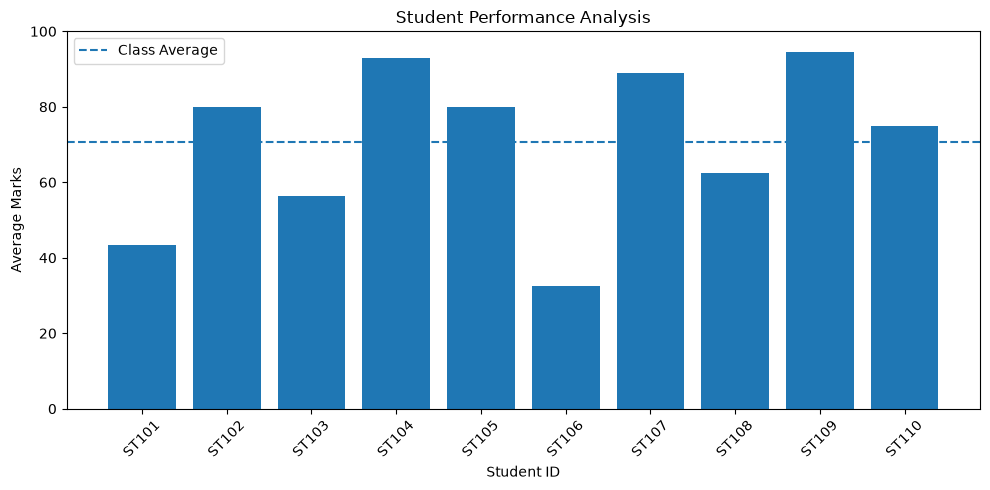

In [10]:
plt.figure(figsize=(10, 5))

plt.bar(
    df["Student_ID"],
    df["Average_Marks"]
)

plt.axhline(
    df["Average_Marks"].mean(),
    linestyle="--",
    label="Class Average"
)

plt.title("Student Performance Analysis")
plt.xlabel("Student ID")
plt.ylabel("Average Marks")
plt.ylim(0, 100)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [12]:
def generate_recommendation(student):
    recommendations = []

    if student["Average_Marks"] < 60:
        recommendations.append("Revise subject fundamentals")

    if student["Attendance"] < 75:
        recommendations.append("Improve class attendance")

    if student["Study_Hours"] < 3:
        recommendations.append("Build a regular study routine")

    if student["Assignments_Completed"] < 7:
        recommendations.append("Complete pending assignments")

    if not recommendations:
        recommendations.append("Maintain current learning habits")

    return " | ".join(recommendations)


df["Study_Recommendation"] = df.apply(
    generate_recommendation,
    axis=1
)

print("PERSONALIZED STUDY RECOMMENDATIONS")
print("=" * 90)

print(
    df[
        ["Student_ID", "Average_Marks", "Study_Recommendation"]
    ].to_string(index=False)
)

PERSONALIZED STUDY RECOMMENDATIONS
Student_ID  Average_Marks                                                                                                  Study_Recommendation
     ST101           43.5 Revise subject fundamentals | Improve class attendance | Build a regular study routine | Complete pending assignments
     ST102           80.0                                                                                      Maintain current learning habits
     ST103           56.5                                 Revise subject fundamentals | Improve class attendance | Complete pending assignments
     ST104           93.0                                                                                      Maintain current learning habits
     ST105           80.0                                                                                      Maintain current learning habits
     ST106           32.5 Revise subject fundamentals | Improve class attendance | Build a regular st

In [14]:
print("=" * 45)
print(" STUDENT PERFORMANCE SUMMARY")
print("=" * 45)

print(f"Total Students: {len(df)}")
print(f"Class Average: {df['Average_Marks'].mean():.2f}")
print(f"Highest Average: {df['Average_Marks'].max():.2f}")
print(f"Lowest Average: {df['Average_Marks'].min():.2f}")

print("\nPerformance Category Summary:")

category_counts = df["Performance_Level"].value_counts()

print(category_counts.to_string())

print("\nAverage Attendance:", f"{df['Attendance'].mean():.2f}%")
print(
    "Average Assignments Completed:",
    f"{df['Assignments_Completed'].mean():.2f}"
)

print("=" * 45)

 STUDENT PERFORMANCE SUMMARY
Total Students: 10
Class Average: 70.65
Highest Average: 94.50
Lowest Average: 32.50

Performance Category Summary:
Performance_Level
Good                 4
Excellent            3
Average              2
Needs Improvement    1

Average Attendance: 79.80%
Average Assignments Completed: 7.60


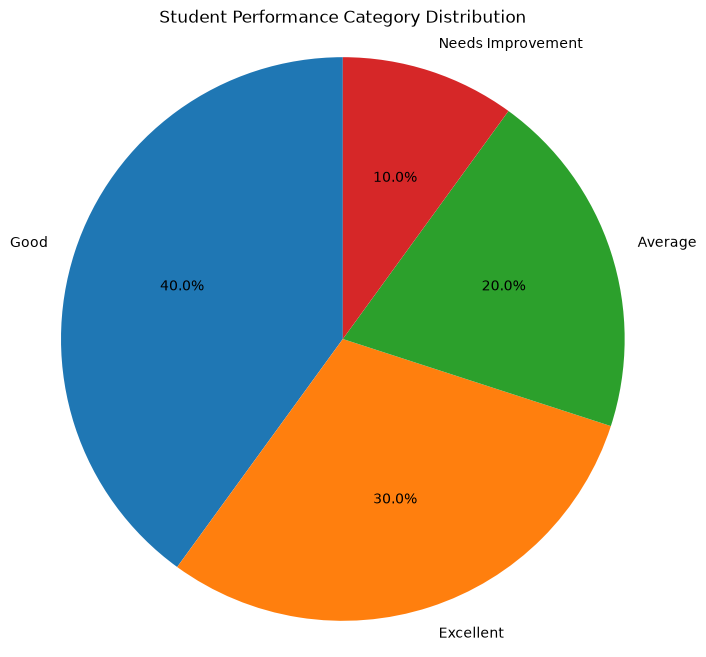

In [16]:
category_counts = df["Performance_Level"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Student Performance Category Distribution")
plt.axis("equal")
plt.show()

In [18]:
report_columns = [
    "Student_ID",
    "Study_Hours",
    "Attendance",
    "Math_Marks",
    "Science_Marks",
    "Assignments_Completed",
    "Average_Marks",
    "Performance_Level",
    "Study_Recommendation"
]

performance_report = df[report_columns].copy()

performance_report.to_csv(
    "student_performance_report.csv",
    index=False
)

print("Performance report exported successfully!")
print("File Name: student_performance_report.csv")
print("Total Records Exported:", len(performance_report))

Performance report exported successfully!
File Name: student_performance_report.csv
Total Records Exported: 10


In [19]:
print("=" * 55)
print(" STUDENT PERFORMANCE PREDICTION SYSTEM")
print(" DAY 14 - PERFORMANCE ANALYSIS MODULE")
print("=" * 55)

print("1. Student dataset created")
print("2. Average marks calculated")
print("3. Performance categories assigned")
print("4. Student ranking generated")
print("5. Performance charts displayed")
print("6. Personalized study recommendations created")
print("7. Class performance summary generated")
print("8. CSV report exported")

print("-" * 55)
print("Total Students Analyzed:", len(df))
print(
    "Overall Class Average:",
    round(df["Average_Marks"].mean(), 2)
)
print("Report File: student_performance_report.csv")
print("=" * 55)

print("Day 14 completed successfully!")

 STUDENT PERFORMANCE PREDICTION SYSTEM
 DAY 14 - PERFORMANCE ANALYSIS MODULE
1. Student dataset created
2. Average marks calculated
3. Performance categories assigned
4. Student ranking generated
5. Performance charts displayed
6. Personalized study recommendations created
7. Class performance summary generated
8. CSV report exported
-------------------------------------------------------
Total Students Analyzed: 10
Overall Class Average: 70.65
Report File: student_performance_report.csv
Day 14 completed successfully!
